# 🐶🐱 Dog vs Cat Classification using CNN

In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2026-04-09 03:21:22.688479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775704882.874423      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775704882.926926      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775704883.348504      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775704883.348544      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775704883.348547      55 computation_placer.cc:177] computation placer alr

Num GPUs Available:  1


In [2]:
import os
import matplotlib.pyplot as plt
import cv2
from PIL import Image

## Dataset
- 25,000 images (12.5k cats, 12.5k dogs)
- Balanced dataset
- Source: Kaggle

## 1. Data Cleaning
Corrupted images were removed and all images were converted to RGB format to ensure stable training.

In [3]:
from PIL import Image
import os

input_folder = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages"
output_folder = "/kaggle/working/cleaned_data"

os.makedirs(output_folder, exist_ok=True)

for root, dirs, files in os.walk(input_folder):
    for file in files:
        input_path = os.path.join(root, file)

        relative_path = os.path.relpath(root, input_folder)
        save_dir = os.path.join(output_folder, relative_path)
        os.makedirs(save_dir, exist_ok=True)

        output_path = os.path.join(save_dir, file)

        try:
            img = Image.open(input_path)
            img.verify()  
            img = Image.open(input_path).convert("RGB")
            img.save(output_path, "JPEG")
        except:
            print("Removed (corrupt):", input_path)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [4]:
base_path = "/kaggle/working/cleaned_data"
categories = ['Cat', 'Dog']

In [5]:
for category in categories:
    path = os.path.join(base_path, category)
    num_images = len(os.listdir(path))
    print(f"{category}: {num_images}")

Cat: 12499
Dog: 12499


In [6]:
train_dir = "/kaggle/working/cleaned_data"

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## 2. Data Augmentation & Preprocessing
Apply augmentation (rotation, zoom, flip) to improve generalization.
80/20 train-validation split.

In [8]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [9]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [10]:
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=128,
    class_mode='binary',
    subset='training'
)

Found 20000 images belonging to 2 classes.


In [11]:
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=128,
    class_mode='binary',
    subset='validation'
)

Found 4998 images belonging to 2 classes.


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

## 3. Model Architecture
A custom CNN architecture is used for binary image classification.

In [13]:
model = Sequential([
    Input(shape=(224, 224, 3)), 
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

I0000 00:00:1775705222.064009      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [14]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [17]:
checkpoint = ModelCheckpoint(
    "/kaggle/working/best_cnn_model.h5",  # save location
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [18]:
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [19]:
mixed_precision.set_global_policy('mixed_float16')
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.00001, verbose=1),
    checkpoint  
]

## 4. Training
Model trained using callbacks like EarlyStopping and ReduceLROnPlateau for better convergence.

In [20]:
history = model.fit(
    train_generator,
    epochs=50, 
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1775705229.166630     181 service.cc:152] XLA service 0x79d8b0005640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775705229.166683     181 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775705229.611972     181 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-09 03:27:16.856685: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.5 = (f32[64,32,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,32,111,111]{3,2,1,0} %bitcast.5853, f32[128,64,109,109]{3,2,1,0} %bitcast.5917), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/sequential_1/conv2d_1_2/convolution/Conv2DBackpropFilter" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_co

  1/157 ━━━━━━━━━━━━━━━━━━━━ 34:35 13s/step - accuracy: 0.5391 - loss: 0.6922

I0000 00:00:1775705239.343321     181 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

157/157 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.9331 - loss: 0.1721 - val_accuracy: 0.9222 - val_loss: 0.1890 - learning_rate: 2.0000e-04
Epoch 22/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9388 - loss: 0.1589
Epoch 22: val_loss improved from 0.18904 to 0.17512, saving model to /kaggle/working/best_cnn_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.9388 - loss: 0.1590 - val_accuracy: 0.9278 - val_loss: 0.1751 - learning_rate: 2.0000e-04
Epoch 23/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9311 - loss: 0.1717
Epoch 23: val_loss improved from 0.17512 to 0.17279, saving model to /kaggle/working/best_cnn_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.9311 - loss: 0.1717 - val_accuracy: 0.9294 - val_loss: 0.1728 - learning_rate: 2.0000e-04
Epoch 24/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9349 - loss: 0.1617
Epoch 24: val_loss did not improve from 0.17279
157/157 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.9349 - loss: 0.1617 - val_accuracy: 0.9226 - val_loss: 0.1929 - learning_rate: 2.0000e-04
Epoch 25/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9353 - loss: 0.1617
Epoch 25: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 25: val_loss did not improve from 0.17279
157/157 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.9353 - loss: 0.1616 - val_accuracy: 0.9262 - val_loss: 0.1829 - learning_rate: 2.0000e-04
Epoch 26/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9427 - loss: 0.1448
Epoch 26: val_loss improved from 0.17279 to 0.16764, saving model to /kaggle/working/best_cnn_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.9427 - loss: 0.1448 - val_accuracy: 0.9322 - val_loss: 0.1676 - learning_rate: 4.0000e-05
Epoch 27/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9396 - loss: 0.1467
Epoch 27: val_loss did not improve from 0.16764
157/157 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.9396 - loss: 0.1467 - val_accuracy: 0.9322 - val_loss: 0.1713 - learning_rate: 4.0000e-05
Epoch 28/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9451 - loss: 0.1452
Epoch 28: ReduceLROnPlateau reducing learning rate to 1e-05.

Epoch 28: val_loss did not improve from 0.16764
157/157 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.9451 - loss: 0.1453 - val_accuracy: 0.9312 - val_loss: 0.1697 - learning_rate: 4.0000e-05
Epoch 29/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9439 - loss: 0.1424
Epoch 29: val_loss did not improve from 0.16764
157/157 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.9439 - loss: 0.1424 - val_accuracy: 0.9308

157/157 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.9427 - loss: 0.1428 - val_accuracy: 0.9312 - val_loss: 0.1676 - learning_rate: 1.0000e-05
Epoch 31/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9420 - loss: 0.1496
Epoch 31: val_loss did not improve from 0.16759
157/157 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.9420 - loss: 0.1496 - val_accuracy: 0.9314 - val_loss: 0.1723 - learning_rate: 1.0000e-05
Epoch 32/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9428 - loss: 0.1462
Epoch 32: val_loss did not improve from 0.16759
157/157 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.9428 - loss: 0.1462 - val_accuracy: 0.9320 - val_loss: 0.1700 - learning_rate: 1.0000e-05
Epoch 33/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9446 - loss: 0.1450
Epoch 33: val_loss did not improve from 0.16759
157/157 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - accuracy: 0.9446 - loss: 0.1450 - val_accuracy: 0.9306 - val_loss: 0.1726 - learning_rate: 1.0000e-05
Epoch 34/50
15

In [21]:
model.save("/kaggle/working/final_model.h5")

## 5. Results

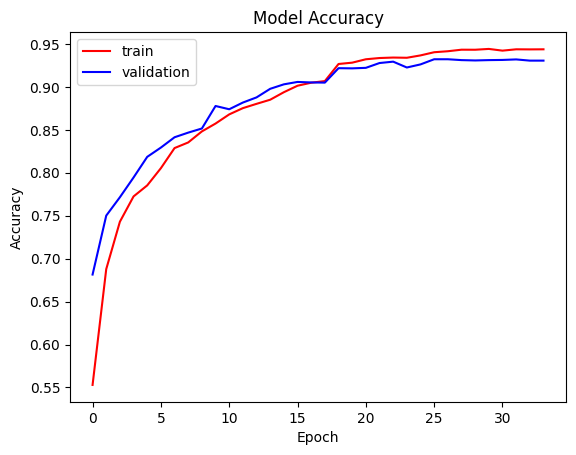

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

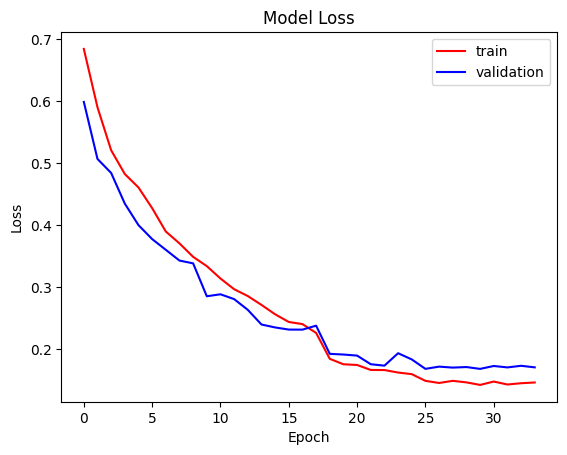

In [23]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {train_accuracy:.4f}")
print(f"Final Validation Accuracy: {val_accuracy:.4f}")
print(f"Final Training Loss: {train_loss:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")

Final Training Accuracy: 0.9438
Final Validation Accuracy: 0.9306
Final Training Loss: 0.1457
Final Validation Loss: 0.1701


In [32]:
def preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = img_array / 255.0  
    img_array = np.expand_dims(img_array, axis=0) 
    return img_array

In [27]:
import numpy as np

In [33]:
image_path_1 = '/kaggle/input/datasets/raghavgupta211/testing/cat.jpg'
image_path_2 = '/kaggle/input/datasets/raghavgupta211/testing/dog.jpg'

processed_image_1 = preprocess_image(image_path_1)
processed_image_2 = preprocess_image(image_path_2)

In [34]:
prediction_1 = model.predict(processed_image_1)[0][0]
prediction_2 = model.predict(processed_image_2)[0][0]

# Interpret predictions with proper confidence percentage
if prediction_1 > 0.5:
    label_1 = 'Dog'
    conf_1 = prediction_1 * 100
else:
    label_1 = 'Cat'
    conf_1 = (1 - prediction_1) * 100

if prediction_2 > 0.5:
    label_2 = 'Dog'
    conf_2 = prediction_2 * 100
else:
    label_2 = 'Cat'
    conf_2 = (1 - prediction_2) * 100

print(f"Prediction for Image 1: {label_1} (Confidence: {conf_1:.2f}%)")
print(f"Prediction for Image 2: {label_2} (Confidence: {conf_2:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediction for Image 1: Cat (Confidence: 100.00%)
Prediction for Image 2: Dog (Confidence: 99.26%)


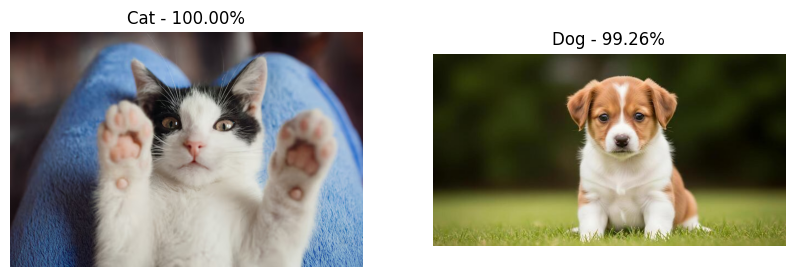

In [37]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
img1_display = Image.open(image_path_1)
plt.imshow(img1_display)
plt.title(f"{label_1} - {conf_1:.2f}%")
plt.axis('off')

plt.subplot(1, 2, 2)
img2_display = Image.open(image_path_2)
plt.imshow(img2_display)
plt.title(f"{label_2} - {conf_2:.2f}%")
plt.axis('off')

plt.show()